# 📚 Importing Libraries

In [4]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import poisson
import matplotlib as mpl

# ⚙️ Dynamic style configuration
mpl_params = {
    "text.usetex": True,   # use LaTeX for text (False = off)
    "font.family": "serif", # font style
    "figure.dpi": 120,      # image resolution
    "axes.titlesize": 14,   # title font size
    "axes.labelsize": 12    # label font size
}

mpl.rcParams.update(mpl_params)


# 🌌 Quantum Network Simulator

In [5]:
class QuantumNetworkSimulator:
    """
    Simulator for quantum photonic networks using Waxman random graphs.

    Attributes
    ----------
    R : float
        Maximum radius for node placement.
    aL : float
        Characteristic length scale for edge probability.
    b : float
        Scaling factor for edge probability.
    g : float
        Attenuation factor for photon transmission.
    np_photons : int
        Number of photons used in transmission.
    A_value : float
        Constant parameter used for node coloring in plots.
    """

    def __init__(self, R=1800, aL=226, b=1, g=0.2, np_photons=1000, A_value=5.2e4):
        """
        Initialize the simulator with model parameters.
        """
        self.R = R
        self.aL = aL
        self.b = b
        self.g = g
        self.np_photons = np_photons
        self.A_value = A_value

    def generate_waxman_graph(self, N):
        """
        Generate a Waxman random geometric graph.

        Parameters
        ----------
        N : int
            Number of nodes.

        Returns
        -------
        G : networkx.Graph
            Fiber network with weighted edges.
        nodes : ndarray
            Array with the (x, y) coordinates of the nodes.
        """
        G = nx.Graph()
        G.add_nodes_from(range(N))
        r = self.R * np.sqrt(np.random.uniform(0, 1, N))
        theta = np.random.uniform(0, 2 * np.pi, N)
        x = r * np.cos(theta)
        y = r * np.sin(theta)
        nodes = np.column_stack((x, y))
        dij = np.sqrt((x[:, None] - x)**2 + (y[:, None] - y)**2)
        Pij = self.b * np.exp(-dij / self.aL)
        mask = np.triu(np.random.uniform(0, 1, size=(N, N)) < Pij, 1)
        for i, j in zip(*np.where(mask)):
            G.add_edge(i, j, weight=dij[i, j])
        return G, nodes

    def generate_photonic_network(self, G, nodes):
        """
        Generate the photonic network from the fiber network.

        Each fiber link has a probability of surviving based on distance,
        attenuation, and number of photons.

        Parameters
        ----------
        G : networkx.Graph
            Fiber network.
        nodes : ndarray
            Node coordinates.

        Returns
        -------
        H : networkx.Graph
            Photonic network with surviving edges.
        """
        H = nx.Graph()
        H.add_nodes_from(G.nodes())
        for i, j, data in G.edges(data=True):
            dij = data['weight']
            pij = 10**(-self.g * dij / 10)
            Pij = 1 - (1 - pij)**self.np_photons
            if np.random.rand() < Pij:
                H.add_edge(i, j, weight=dij)
        return H

    def calculate_largest_cluster_size(self, G):
        """
        Compute the size of the largest connected component.

        Parameters
        ----------
        G : networkx.Graph
            Input graph.

        Returns
        -------
        int
            Number of nodes in the largest cluster.
        """
        if len(G) == 0:
            return 0
        largest_cc = max(nx.connected_components(G), key=len, default=set())
        return len(largest_cc)

    def plot_combined(self, ax, nodes, fiber_net, photonic_net, N, ng_over_n, label):
        """
        Plot fiber and photonic networks together.

        - Gray edges: all fiber links.
        - Red edges: links that survived in the photonic network.
        - Node colors: indicate relative degree based on a Poisson distribution.

        Parameters
        ----------
        ax : matplotlib.axes.Axes
            Axis to draw on.
        nodes : ndarray
            Node coordinates.
        fiber_net : networkx.Graph
            Original fiber network.
        photonic_net : networkx.Graph
            Photonic network.
        N : int
            Number of nodes.
        ng_over_n : float
            Fraction of nodes in the largest cluster.
        label : str
            Label for subplot (a, b, c...).
        """
        scale_factor = 0.85
        pos = {i: (x * scale_factor, y * scale_factor) for i, (x, y) in enumerate(nodes)}
        degrees = dict(photonic_net.degree())
        density = N / (np.pi * self.R**2)
        lambda_param = self.A_value * density
        node_colors = [plt.cm.winter(poisson.cdf(degrees.get(node, 0), lambda_param)) for node in range(N)]

        nx.draw_networkx_edges(fiber_net, pos, edge_color='gray', alpha=0.2, ax=ax)
        nx.draw_networkx_edges(photonic_net, pos, edge_color='red', alpha=0.7, ax=ax)
        nx.draw_networkx_nodes(photonic_net, pos, node_color=node_colors, node_size=20, ax=ax)

        ax.set_xlim(-self.R, self.R)
        ax.set_ylim(-self.R, self.R)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal', adjustable='box')

        ax.text(0.02, 0.02, f"({label})", transform=ax.transAxes,
                verticalalignment='bottom', horizontalalignment='left',
                fontsize=12, fontweight='bold')

        ax.text(0.05, 0.90,
                f"$N_{{G}}/N = {ng_over_n*100:.1f}\\%$   $N = {N}$",
                transform=ax.transAxes,
                fontsize=10, ha='left',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.85))

    def run_simulation(self, Ns, labels, filename="quantum_networks.png"):
        """
        Run multiple simulations and plot them in a grid.

        Parameters
        ----------
        Ns : list of int
            List of network sizes.
        labels : list of str
            Subplot labels.
        filename : str, optional
            File to save the figure (default: "quantum_networks.png").
        """
        fig, axes = plt.subplots(2, 3, figsize=(15, 9))  # layout 2x3
        for ax, N, label in zip(axes.flatten(), Ns, labels):
            fiber_net, nodes = self.generate_waxman_graph(N)
            photonic_net = self.generate_photonic_network(fiber_net, nodes)
            ng_over_n = self.calculate_largest_cluster_size(photonic_net) / N
            self.plot_combined(ax, nodes, fiber_net, photonic_net, N, ng_over_n, label)

        plt.tight_layout()
        plt.savefig(filename, dpi=700)
        plt.show()


# ▶️ Example usage

This block runs the simulator for different network sizes (**Ns**) and generates a **2x3 grid of plots** labeled *(a, b, c, d, e, f).*  
The figure is saved as **`quantum_networks.png`** 🖼️💾


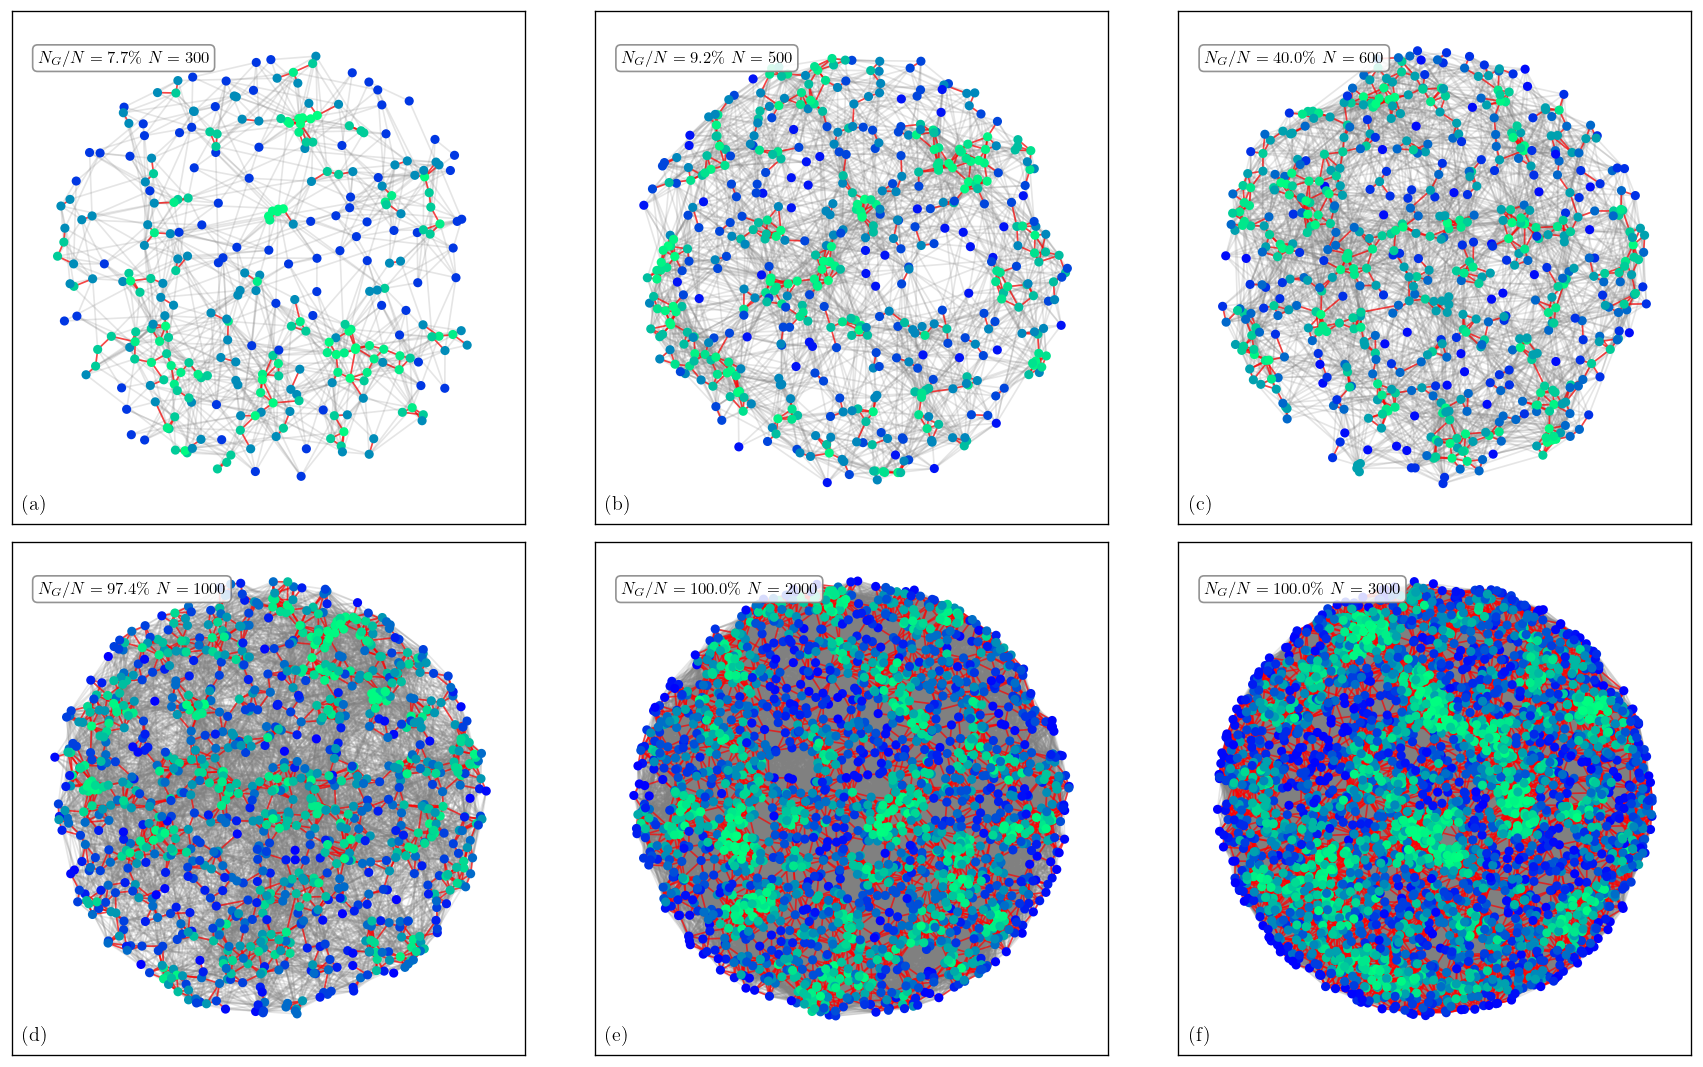

In [6]:
if __name__ == "__main__":
    simulator = QuantumNetworkSimulator()
    Ns = [300, 500, 600, 1000, 2000, 3000]
    labels = ['a', 'b', 'c', 'd', 'e', 'f']
    simulator.run_simulation(Ns, labels)